In [1]:
!pip install catboost -q
!pip install xgboost -q
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install lightgbm
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Tree Models
from sklearn.tree import DecisionTreeClassifier

# Linear Models
from sklearn.linear_model import LogisticRegression

# Support Vector Machine
from sklearn.svm import SVC

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# External Boosting Libraries
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Visualization
!pip install folium
import folium
from folium.plugins import HeatMap
import plotly.express as px

pd.set_option('display.max_columns', 32)

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/main/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.isnull().sum()
df.shape

(119390, 32)

In [5]:
null1 =pd.DataFrame({
    'null values': df.isnull().sum(),
    'percentage':(df.isnull().sum())/(df.shape[0]*(100))
})
null1

,null values,percentage
hotel,0,0.000000e+00
is_canceled,0,0.000000e+00
lead_time,0,0.000000e+00
arrival_date_year,0,0.000000e+00
arrival_date_month,0,0.000000e+00
arrival_date_week_number,0,0.000000e+00
arrival_date_day_of_month,0,0.000000e+00
stays_in_weekend_nights,0,0.000000e+00
stays_in_week_nights,0,0.000000e+00
adults,0,0.000000e+00


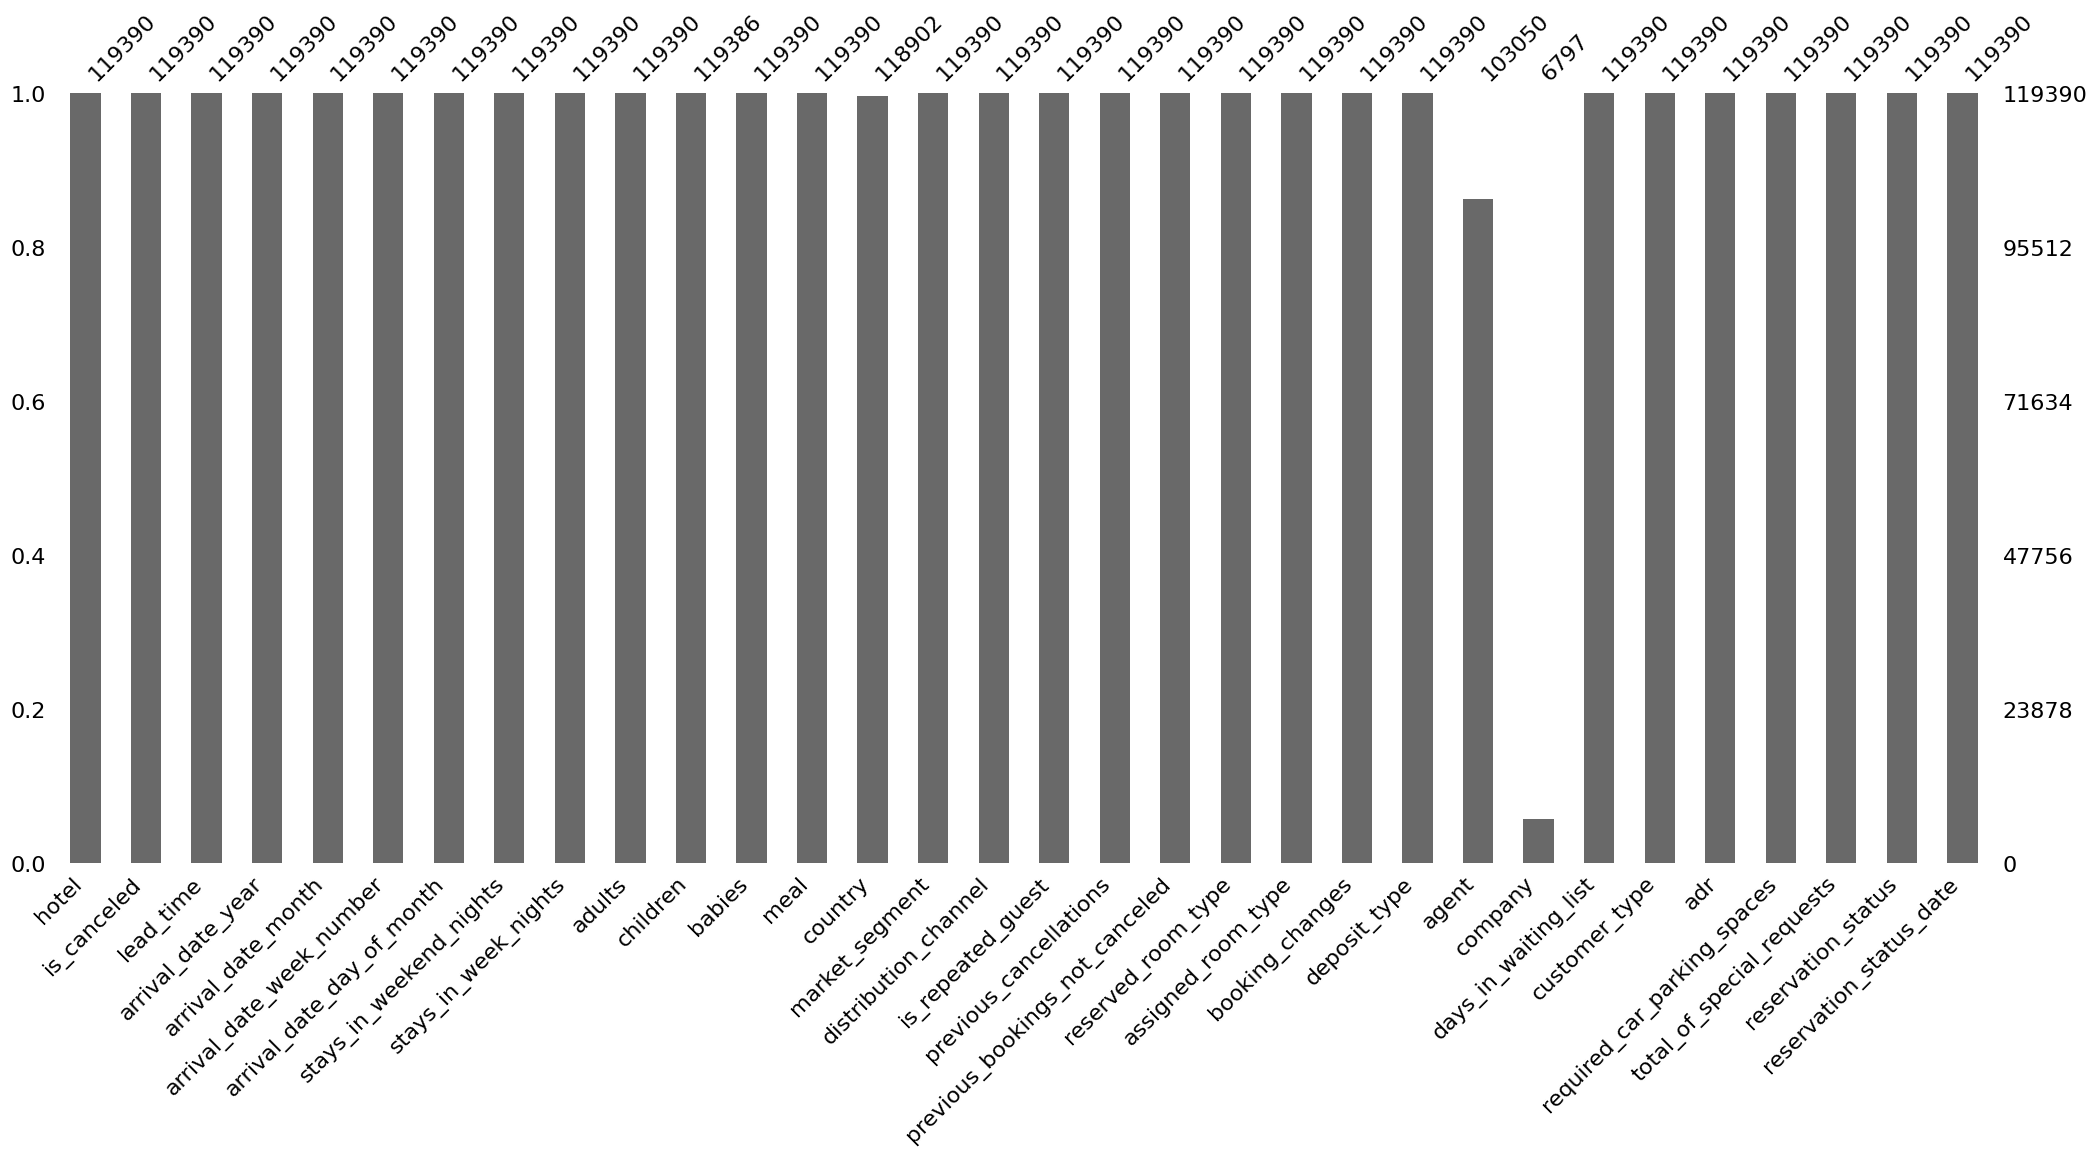

In [6]:
msno.bar(df)
plt.show()

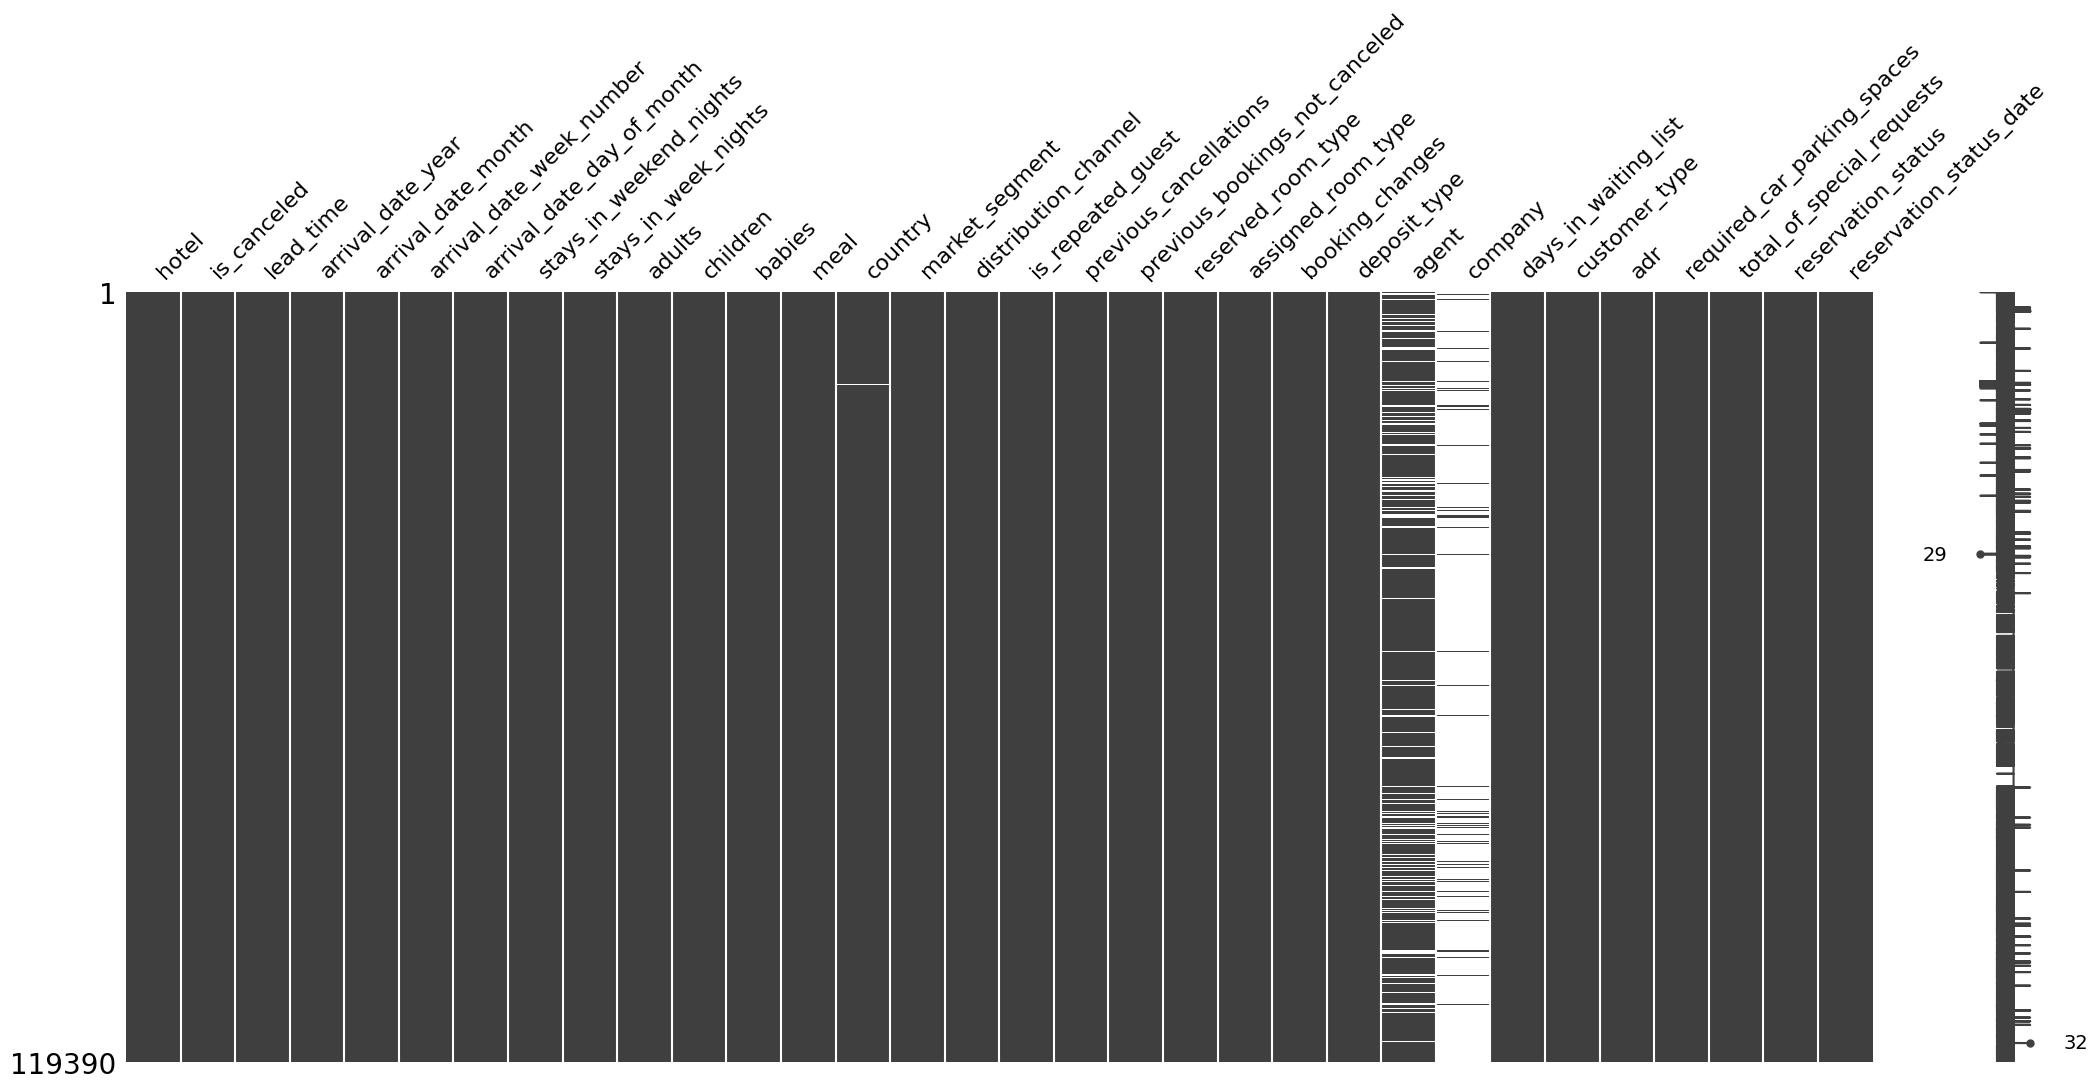

In [7]:
msno.matrix(df)
plt.show()

In [8]:
df.fillna(0,inplace=True)
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [9]:
df.adr

0           0.00
1           0.00
2          75.00
3          75.00
4          98.00
           ...  
119385     96.14
119386    225.43
119387    157.71
119388    104.40
119389    151.20
Name: adr, Length: 119390, dtype: float64

In [10]:
df2 = df[(df.adults == 0) & (df.babies == 0) & (df.children == 0)]
df2.shape

(180, 32)

In [11]:
df3=df.drop(['adults', 'babies', 'children'], axis=1)
df3.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [12]:
df3.shape

(119390, 29)

In [13]:
df3.country.value_counts().reset_index()

,country,count
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
...,...,...
173,MRT,1
174,KIR,1
175,SDN,1
176,ATF,1


In [14]:
df[df.is_canceled==0]['country'].value_counts().reset_index(name='guests')

,country,guests
0,PRT,21071
1,GBR,9676
2,FRA,8481
3,ESP,6391
4,DEU,6069
...,...,...
161,KIR,1
162,ATF,1
163,TJK,1
164,SLE,1
